
## 1. Import necessary libraries.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
random.seed(42)
%matplotlib inline
plt.rcParams.update({'font.size': 22})
sns.set_theme(color_codes=True)
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')



## 2. Loading the dataset

In [6]:
df= pd.read_csv('/content/IPL_B2B_Dataset.csv')

In [7]:
df.head()

,Index,batting_team,bowling_team,city,runs_left,balls_left,wickets,target_runs,cur_run_rate,req_run_rate,result
0,0,Royal Challengers Bangalore,Sunrisers Hyderabad,Hyderabad,207,119,10,208,6.0,10.43697479,0
1,1,Royal Challengers Bangalore,Sunrisers Hyderabad,Hyderabad,207,118,10,208,3.0,10.52542373,0
2,2,Royal Challengers Bangalore,Sunrisers Hyderabad,Hyderabad,207,117,10,208,2.0,10.61538462,0
3,3,Royal Challengers Bangalore,Sunrisers Hyderabad,Hyderabad,205,116,10,208,4.5,10.60344828,0
4,4,Royal Challengers Bangalore,Sunrisers Hyderabad,Hyderabad,201,115,10,208,8.4,10.48695652,0


**Next we take a look at some certain information(index, data type, column names, non-null values and memory usage)**

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72413 entries, 0 to 72412
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Index         72413 non-null  int64  
 1   batting_team  72413 non-null  object 
 2   bowling_team  72413 non-null  object 
 3   city          71581 non-null  object 
 4   runs_left     72413 non-null  int64  
 5   balls_left    72413 non-null  int64  
 6   wickets       72413 non-null  int64  
 7   target_runs   72413 non-null  int64  
 8   cur_run_rate  72413 non-null  float64
 9   req_run_rate  72408 non-null  object 
 10  result        72413 non-null  int64  
dtypes: float64(1), int64(6), object(4)
memory usage: 6.1+ MB


Next we look at some descriptive statistics of our dataset such as the count, mean, median, standard deviation, the quartiles, maximum and minimum.

In [9]:
df.describe()

,Index,runs_left,balls_left,wickets,target_runs,cur_run_rate,result
count,72413.000000,72413.000000,72413.000000,72413.000000,72413.000000,72413.000000,72413.000000
mean,36206.000000,93.258379,62.657078,7.535967,166.583956,7.439523,0.525624
std,20903.976858,50.021962,33.404593,2.138637,29.282200,2.275850,0.499346
min,0.000000,-15.000000,-2.000000,0.000000,66.000000,0.000000,0.000000
25%,18103.000000,54.000000,35.000000,6.000000,147.000000,6.257143,0.000000
50%,36206.000000,93.000000,63.000000,8.000000,166.000000,7.480519,1.000000
75%,54309.000000,131.000000,92.000000,9.000000,186.000000,8.682353,1.000000
max,72412.000000,250.000000,119.000000,10.000000,251.000000,42.000000,1.000000


### We drop the index column.

In [10]:
df = df.drop(['Index'], axis=1)

# 3. Handling missing values



We store the number of samples and null features.


In [11]:
n_samples = df.shape[0]
number_of_null_features = (df.isnull().sum()>0).sum()



We use pie charts to visualize the features containing null values.


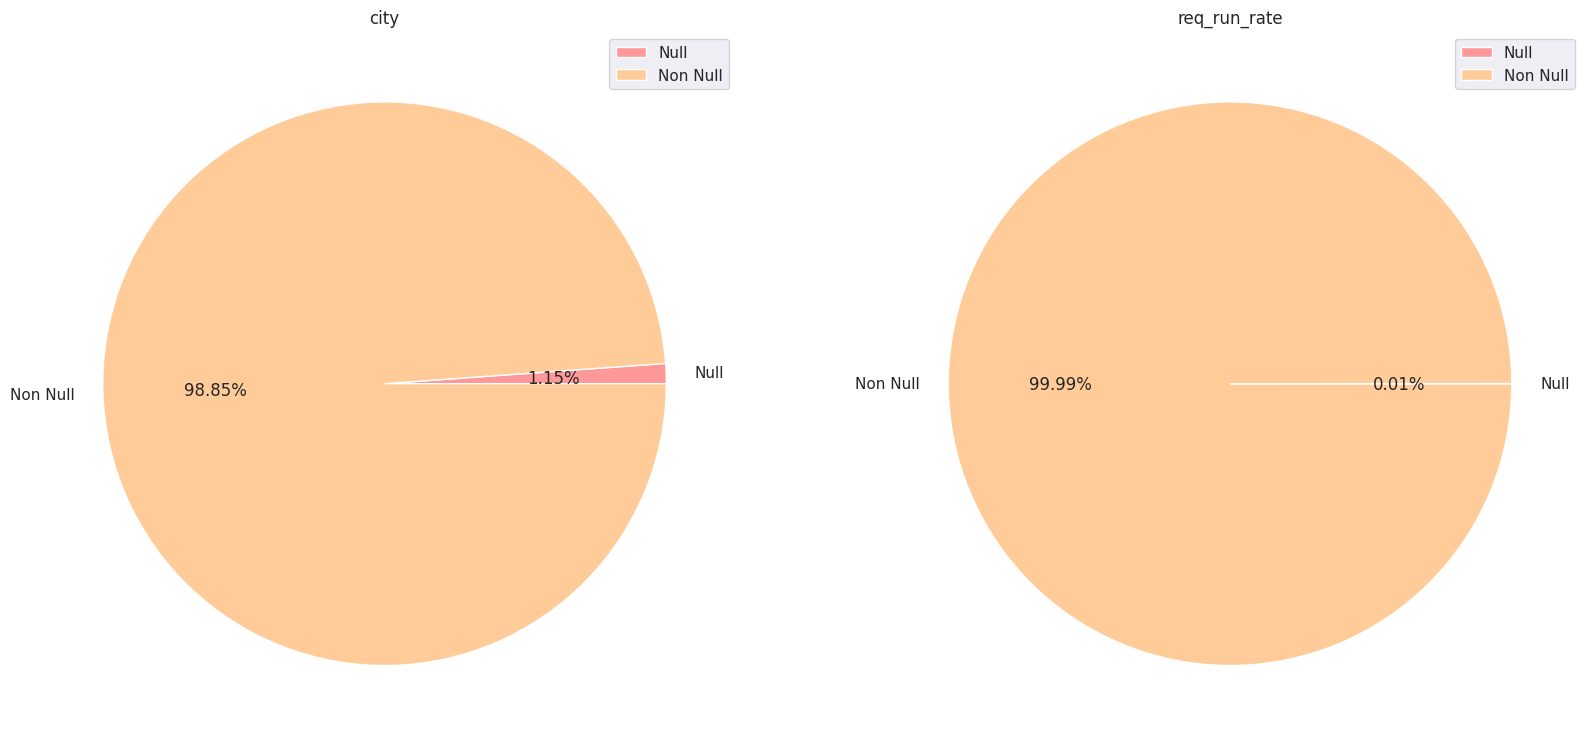

In [12]:
figure, ax = plt.subplots(1,number_of_null_features, figsize=(20, 25))
colors = ['#ff9999', '#ffcc99']
i = 0
j = 0
for col in df.columns:
    n_null = df[col].isnull().sum()
    if(n_null>0):
        ax[i].title.set_text(col)
        ax[i].pie([n_null,n_samples-n_null], labels=['Null','Non Null'], autopct = '%1.2f%%', colors = colors)
        ax[i].legend()
        i+=1

Observations:

    city column has 98.85% non null data.
    req_run_rate has 99.99% non null data.
    
Conclusion:

    Removing the rows where city and req_run_rate is null will not cause unbalance in the dataset.



In [13]:
df = df.dropna()

In [14]:
df.isnull().sum()

,0
batting_team,0
bowling_team,0
city,0
runs_left,0
balls_left,0
wickets,0
target_runs,0
cur_run_rate,0
req_run_rate,0
result,0


We have successfully removed the null instances from the dataset.

# 4. Encoding categorical features

We first find out which columns contain categorical values.

In [15]:
count=0
obj_col = []
for col in df.columns:
    if (df[col].dtype=='O'):
        count+=1
        obj_col.append(col)
print(f"There are a total of {count} categorical(object) features out of {df.shape[1]} features. And they are:\n")
print(obj_col)

There are a total of 4 categorical(object) features out of 10 features. And they are:

['batting_team', 'bowling_team', 'city', 'req_run_rate']


# 4.1 Encoding batting_team and bowling_team

Since same teams are supposed to be present in both the batting and bowling team list, we can encode them together.

In [16]:
teams = df.batting_team.unique()
print(f"There are {df.batting_team.nunique()} different teams and they are:\n {teams}")

There are 10 different teams and they are:
 ['Royal Challengers Bangalore' 'Delhi Daredevils' 'Mumbai Indians'
 'Kings XI Punjab' 'Kolkata Knight Riders' 'Sunrisers Hyderabad'
 'Rajasthan Royals' 'Chennai Super Kings' 'Deccan Chargers'
 'Delhi Capitals']


In [17]:
for val in teams:
    indices  = df.where(df['batting_team'] == val).index
    team = val+"_bat"
    df[team] = 0
    df[team] = np.where(df['batting_team'] == val, 1, df[team])

    team = val+"_bowl"
    df[team] = 0
    df[team] = np.where(df['bowling_team'] == val, 1, df[team])

Now we can remove the original object columns for batting and bowling teams

In [18]:
df = df.drop(['batting_team', 'bowling_team'], axis = 1)

To visualize the performance of all the 10 teams we will use pie charts.

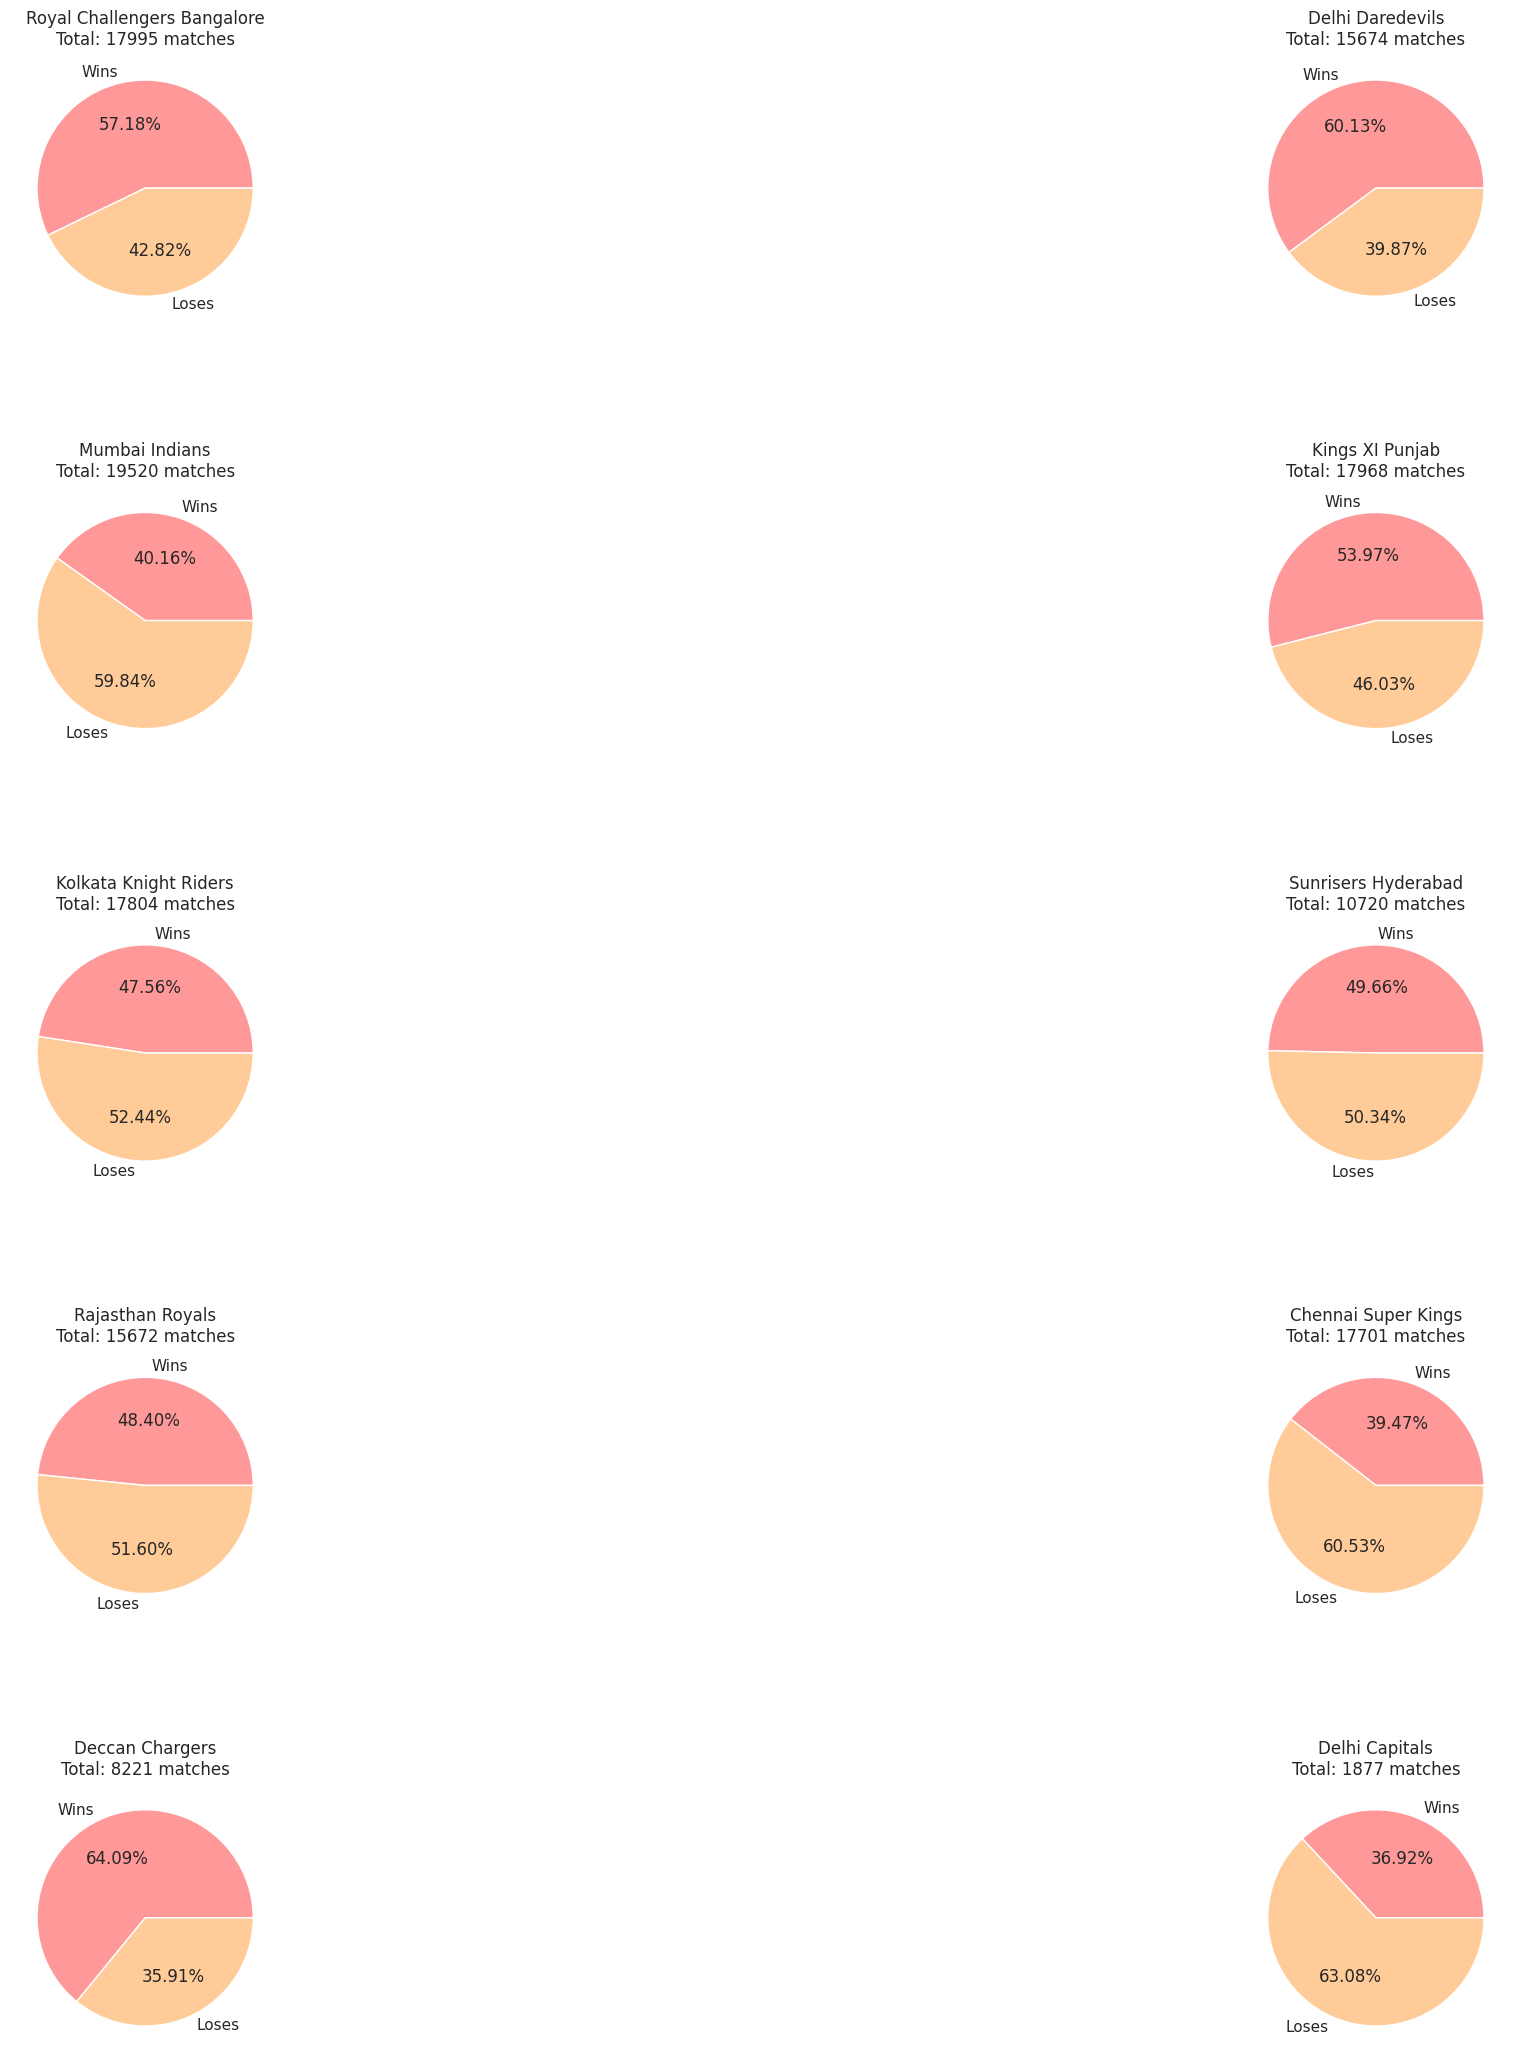

In [19]:


figure, ax = plt.subplots(5,2, figsize=(25, 25))
plt.subplots_adjust(left=0.1,
                    bottom=0.1,
                    right=0.9,
                    top=0.9,
                    wspace=0.6,
                    hspace=0.6)
i = 0
j = 0
for val in teams:
    win = 0
    lose = 0
    bat = df[df[val+'_bat']==1]
    win+=(bat['result']==0).sum()
    lose+=(bat['result']==1).sum()
    bowl = df[df[val+'_bowl']==1]
    win+=(bowl['result']==1).sum()
    lose+=(bowl['result']==0).sum()
    total = win+lose
    ax[j][i].title.set_text(val+f"\nTotal: {total} matches")
    ax[j][i].pie([win,lose], labels=['Wins','Loses'], autopct = '%1.2f%%', colors = colors)
    i+=1
    if(i%2==0):
        j+=1
        i =0



Observations:

    Mumbai Indians played 19520 games which is the highest number of matches.
    Deccan Chargers won in most of the matches they played which is 64.09%.
    Delhi Capitals lost in most of the matches they played which is 63.08%

# 4.2 Encoding city column

In [20]:
print(f"There are {df.city.nunique()} different teams and they are:\n {df.city.unique()}")

There are 29 different teams and they are:
 ['Hyderabad' 'Bangalore' 'Mumbai' 'Indore' 'Kolkata' 'Delhi' 'Chandigarh'
 'Jaipur' 'Chennai' 'Cape Town' 'Port Elizabeth' 'Durban' 'Centurion'
 'East London' 'Johannesburg' 'Kimberley' 'Bloemfontein' 'Ahmedabad'
 'Cuttack' 'Nagpur' 'Dharamsala' 'Visakhapatnam' 'Pune' 'Raipur' 'Ranchi'
 'Abu Dhabi' 'Sharjah' 'Mohali' 'Bengaluru']


In [21]:
df.groupby(['city']).size().reset_index().rename(columns={0:"Total number of matches held"}).sort_values(by = "Total number of matches held", ascending = False)

,city,Total number of matches held
21,Mumbai,9910
19,Kolkata,7805
10,Delhi,7280
14,Hyderabad,6523
8,Chennai,6315
2,Bangalore,5927
16,Jaipur,4835
7,Chandigarh,4572
12,Durban,1725
3,Bengaluru,1610



Observations:

    Most of the matches were held in Mumbai.
    Least number of matches were held in Bloemfontein.
    A lot of matches were held outside India, e.g: Abu Dhabi,



In [22]:


for val in df.city.unique():
    indices  = df.where(df.city == val).index
    df[val] = 0
    df[val] = np.where(df.city == val, 1, df[team])



In [23]:


df.drop(['city'], inplace = True, axis = 1)



# 4.3 Encoding req_run_rate column

In [27]:
print(f"There are {df.req_run_rate.nunique()} different unique values for run rate.")

There are 8995 different unique values for run rate.


In [28]:
df['req_run_rate'].head()

,req_run_rate
0,10.43697479
1,10.52542373
2,10.61538462
3,10.60344828
4,10.48695652



Observations:

It seems like run rate column has numerical values, so we could just transform the values to float64 but before that we need to check if all the values are numeric or not.


In [29]:
import re
numeric = 0
non_numeric= []
for i in df.index:
    str = df.loc[i]['req_run_rate']

    if(bool(re.match("[-]?[0-9]+[.]?[0-9]+$", str))):
        numeric+=1
    elif(bool(re.match("[-]?[0-9]$", str))):
        numeric+=1
    else:
        non_numeric.append(str)

print(f"There are {numeric} numeric values out of {df.shape[0]}")

There are 71342 numeric values out of 71576




So there are some non-numeric values in the req_run_rate features, lets find out what they are.


In [30]:
np.unique(np.array(non_numeric))

array(['#NAME?', 'inf'], dtype='<U6')


Observations:

So we find out that there are some data samples with infinite run rate and other with '#NAME?' run rate.
Conclusions:

    We will drop all data samples where run rate is #NAME?.
    We will impute the inf run rate with a very large value.



In [31]:
# Dropping all instances where req_run_rate is #NAME?
df.drop(df[df['req_run_rate'] == '#NAME?'].index, inplace = True)

We replace all instances where req_run_rate is inf with a large value = 1000000.

In [32]:
df.loc[df[df['req_run_rate']=='inf'].index ,'req_run_rate'] = "1000000"

Next we convert req_run_rate to numeric.

In [33]:
df['req_run_rate'] = df['req_run_rate'].astype('float64', copy = False)

# 5. Correlation among numeric features



We will analyze the numeric columns: runs_left, balls_left, wickets, target_runs, cur_run_rate, req_run_rate and the target column result. To do that first we consider the correlation between these columns.

In [34]:
corr = df.corr()
columns = ['runs_left', 'balls_left', 'wickets', 'target_runs', 'cur_run_rate', 'req_run_rate', 'result']
numeric_corr = corr.loc[columns][columns]

<Axes: >

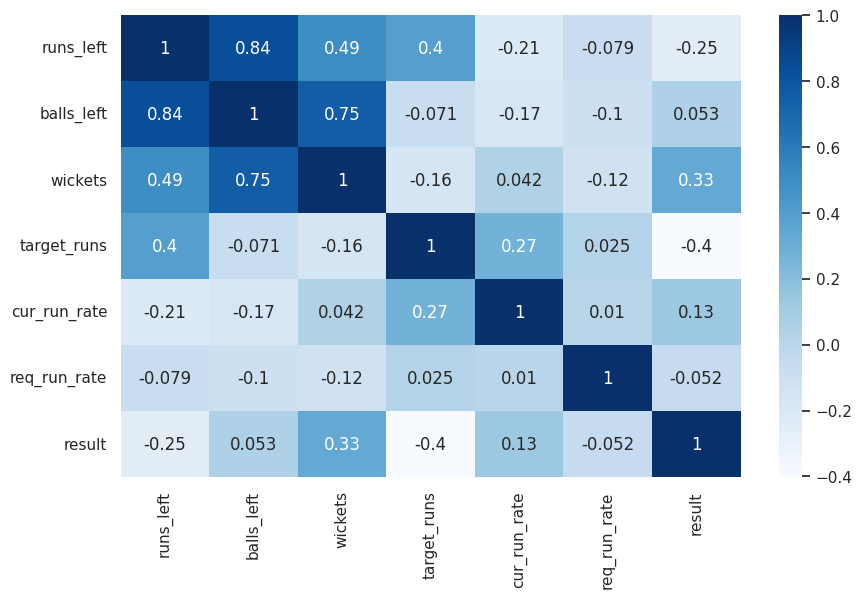

In [35]:


fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(numeric_corr, ax=ax,  cmap="Blues", annot=True)



# Observations:


    runs_left is highly positively correlated with balls_left with a correlation coefficient of 0.84.
    balls_left is highly positively correlated with wickets with a correlation coefficient of 0.75.
    runs_left is moderately positively correlated with wickets with a correlation coefficient of 0.49.
    runs_left is moderately positively correlated with target_runs with a correlation coefficient of 0.40.
    wickets is positively correlated with result with a correlation coefficient of 0.33.
    cur_run_rate is positively correlated with target_runs with a correlation coefficient of 0.27.
    result is highly negatively correlated with target_runs with a correlation coefficient of 0.40.


<Axes: xlabel='runs_left', ylabel='balls_left'>

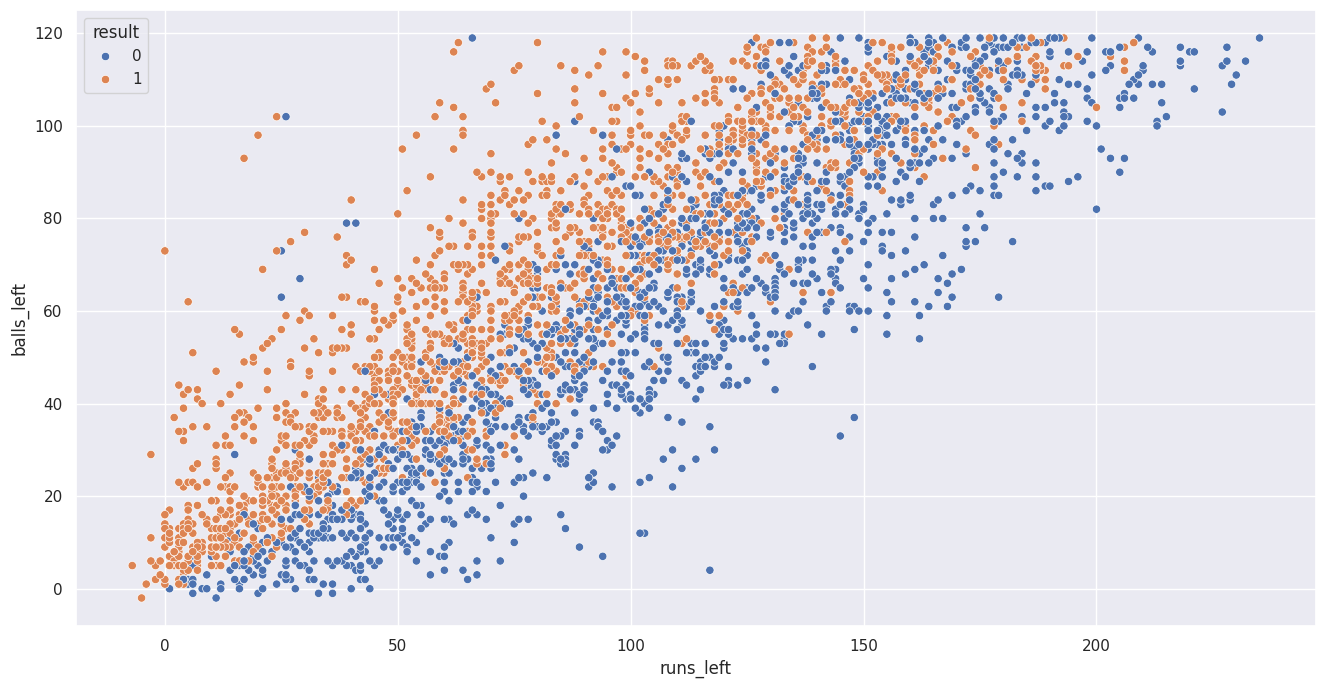

In [36]:
x = df.sample(frac=0.05, replace=True, random_state=1)
plt.figure(figsize=(16,8))
sns.scatterplot(x = 'runs_left', y = 'balls_left',hue='result', data =x)


Observations:

The data seems to be linearly separable on the basis of runs_left and balls_left.


<Axes: xlabel='wickets', ylabel='balls_left'>

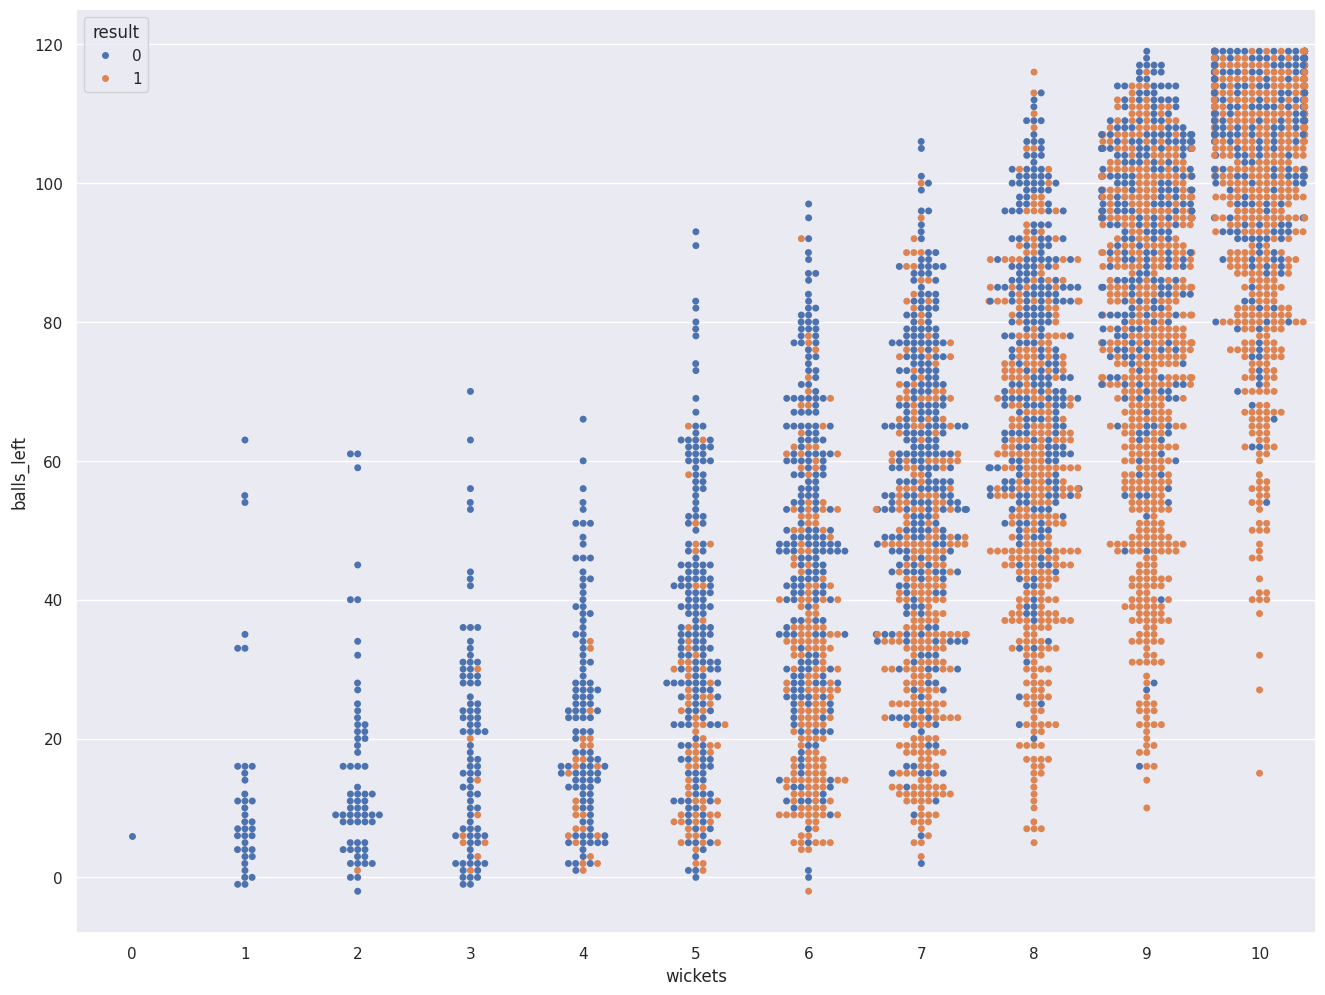

In [38]:


x = df.sample(frac=0.05, replace=True, random_state=1)
plt.figure(figsize=(16,12))
sns.swarmplot(x = 'wickets', y = 'balls_left',hue='result', data =x)

<Axes: xlabel='wickets', ylabel='runs_left'>

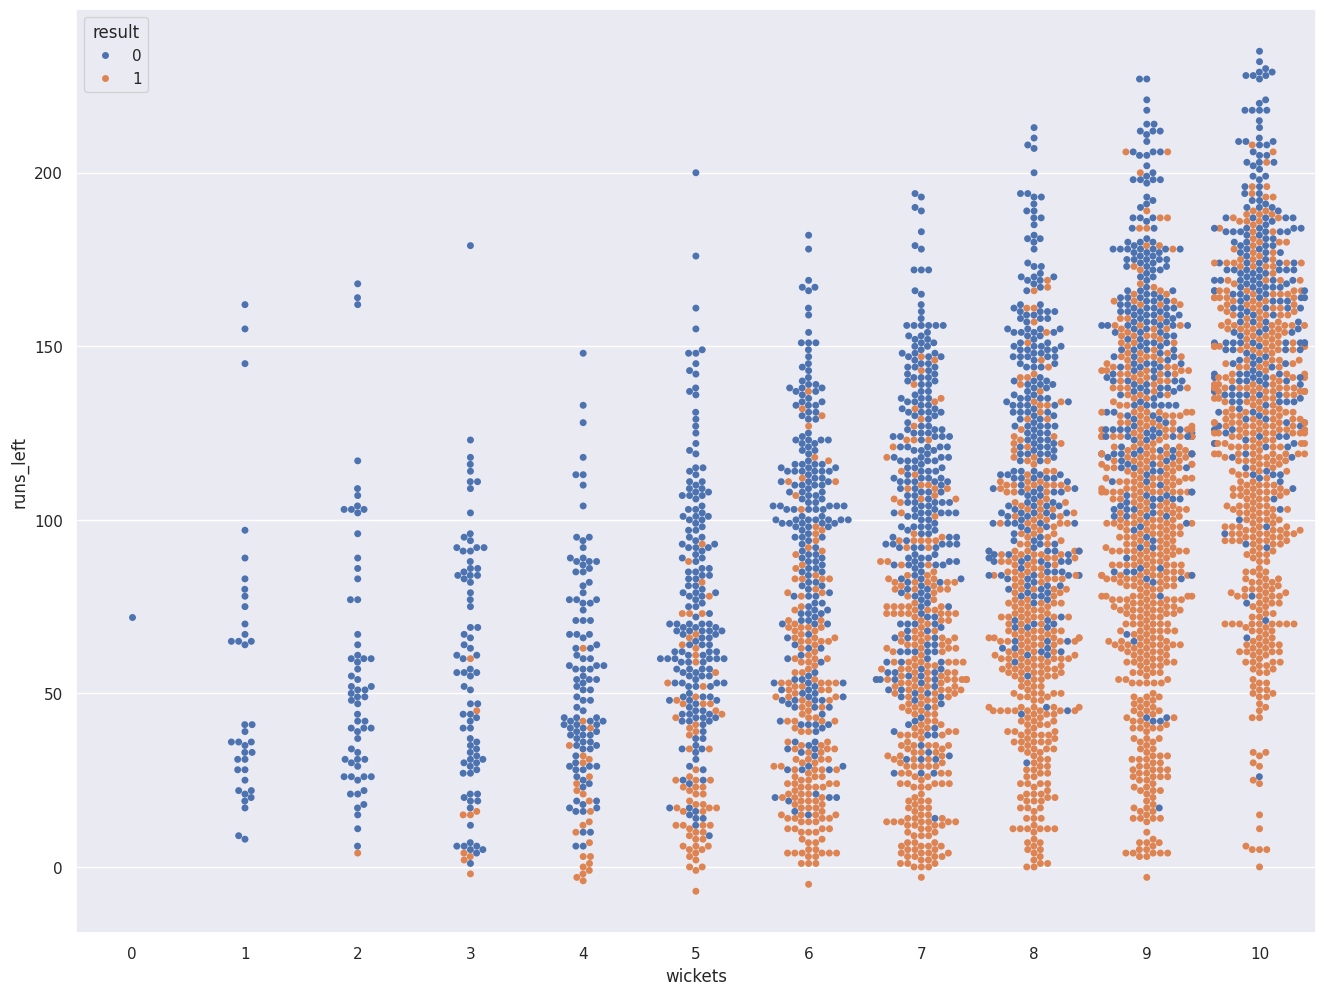

In [39]:
x = df.sample(frac=0.05, replace=True, random_state=1)
plt.figure(figsize=(16,12))
sns.swarmplot(x = 'wickets', y = 'runs_left',hue='result', data =x)

<Axes: xlabel='runs_left', ylabel='target_runs'>

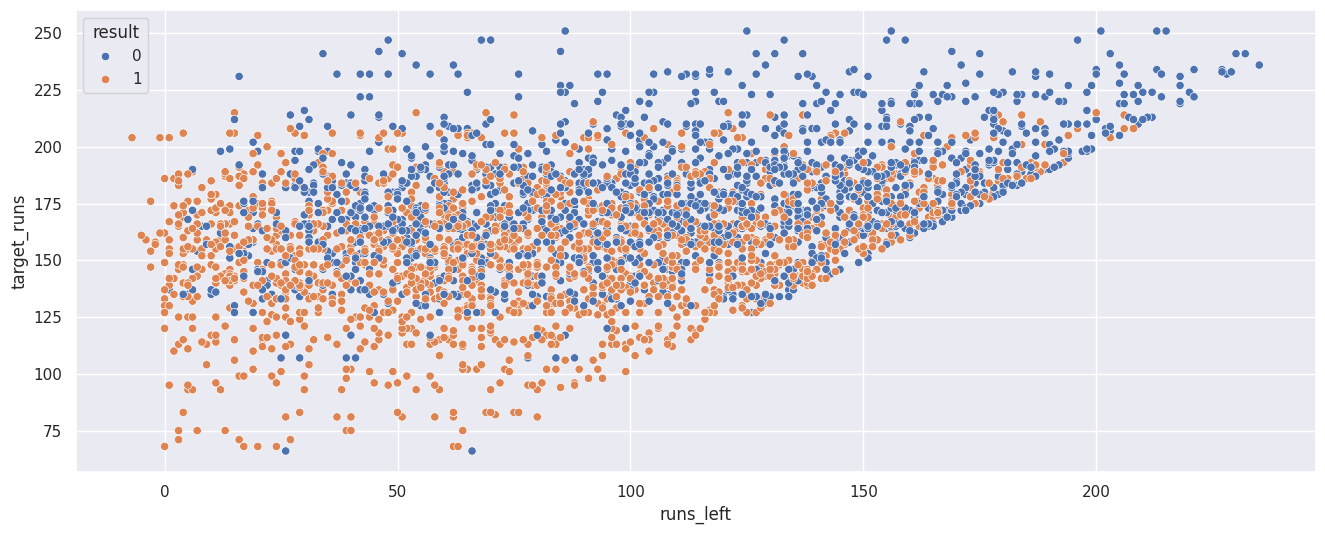

In [40]:
x = df.sample(frac=0.05, replace=True, random_state=1)
plt.figure(figsize=(16,6))
sns.scatterplot(x = 'runs_left', y = 'target_runs',hue='result', data =x)

<Axes: xlabel='result', ylabel='target_runs'>

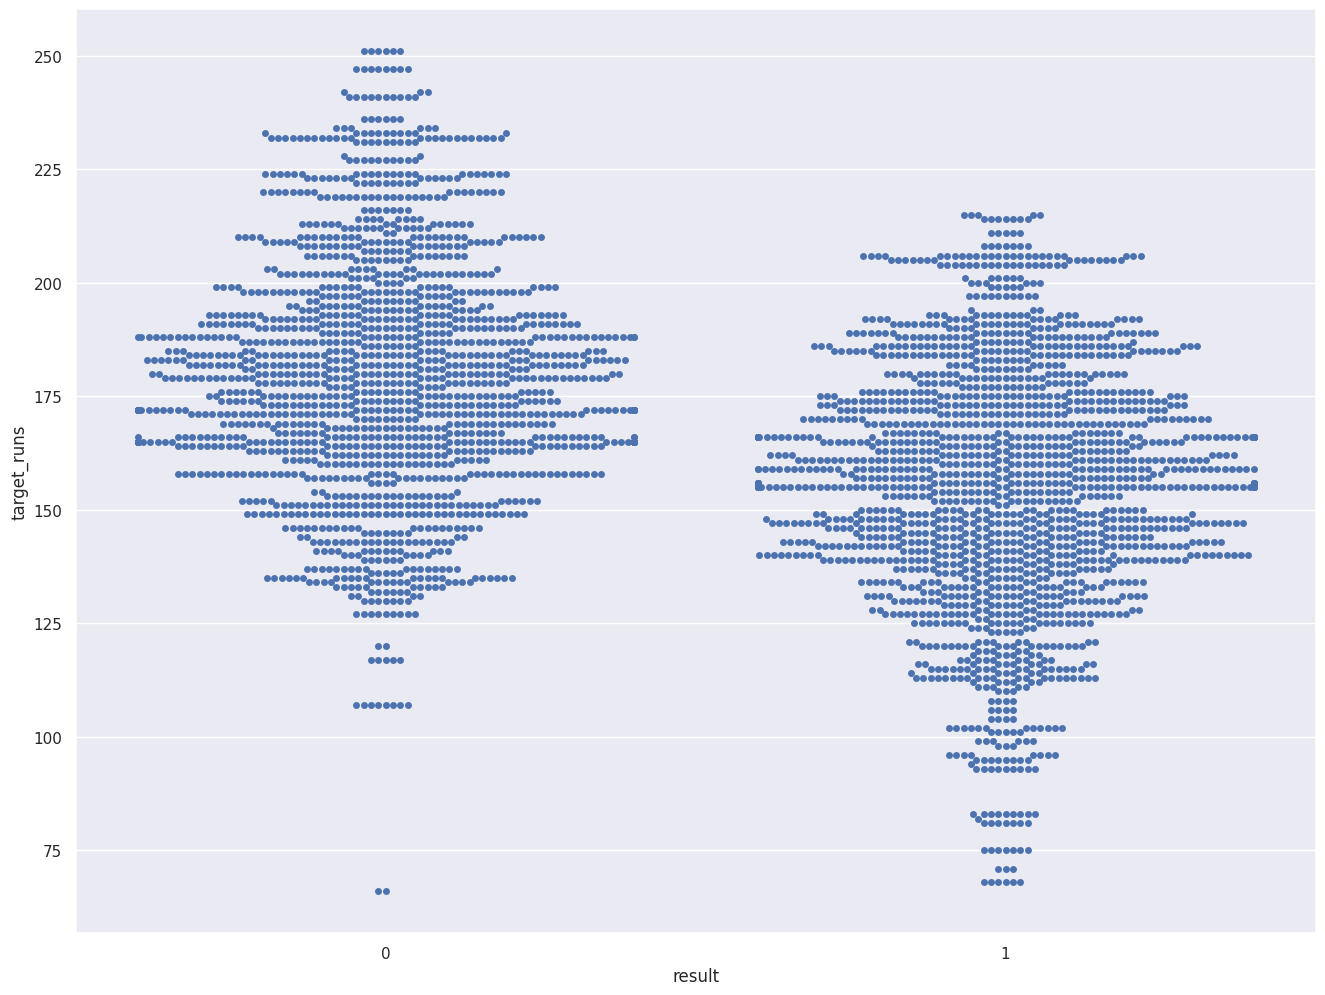

In [41]:
x = df.sample(frac=0.05, replace=True, random_state=1)
plt.figure(figsize=(16,12))
sns.swarmplot(x = 'result', y = 'target_runs', data =x)

# 6. Modelling the dataset

We split the dataset into train and test set.

In [42]:
X = df.drop(['result'], axis=1)
y = df['result']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)



We define a function that calculates accuracy.

In [43]:


def accuracy(pred, test):
    return ((((pred == test).sum())/test.shape)*100).item()



# 6.1 KNN

In [44]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=3)
y_pred = knn.fit(X_train, y_train).predict(X_test)
knn_accuracy = accuracy(y_pred, y_test)

# 6.2 Logistic Regression

In [45]:
from sklearn.linear_model import LogisticRegression
lreg = LogisticRegression(random_state=0).fit(X_train, y_train)
y_pred = lreg.predict(X_test)
lreg_accuracy = accuracy(y_pred, y_test)

# 6.3 Random Forest

In [46]:


from sklearn.ensemble import RandomForestClassifier
rfc = RandomForestClassifier(max_depth=2, random_state=0)
y_pred = rfc.fit(X_train, y_train).predict(X_test)
rfc_accuracy = accuracy(y_pred, y_test)




# 6.4 Decision Tree

In [47]:


from sklearn.tree import DecisionTreeClassifier
dtree = DecisionTreeClassifier(random_state=0)
y_pred = dtree.fit(X_train, y_train).predict(X_test)
dtree_accuracy = accuracy(y_pred, y_test)




# 6.5 Gaussian Naive Bayes

In [49]:
from sklearn.naive_bayes import GaussianNB
gnb = GaussianNB()
y_pred = gnb.fit(X_train, y_train).predict(X_test)
gnb_accuracy = accuracy(y_pred, y_test)



# 7. Evaluation

We compare the accuracy obtained by each of the classifiers on the test set in this section. A bar chart is plot to visualize the comparison.

<Axes: >

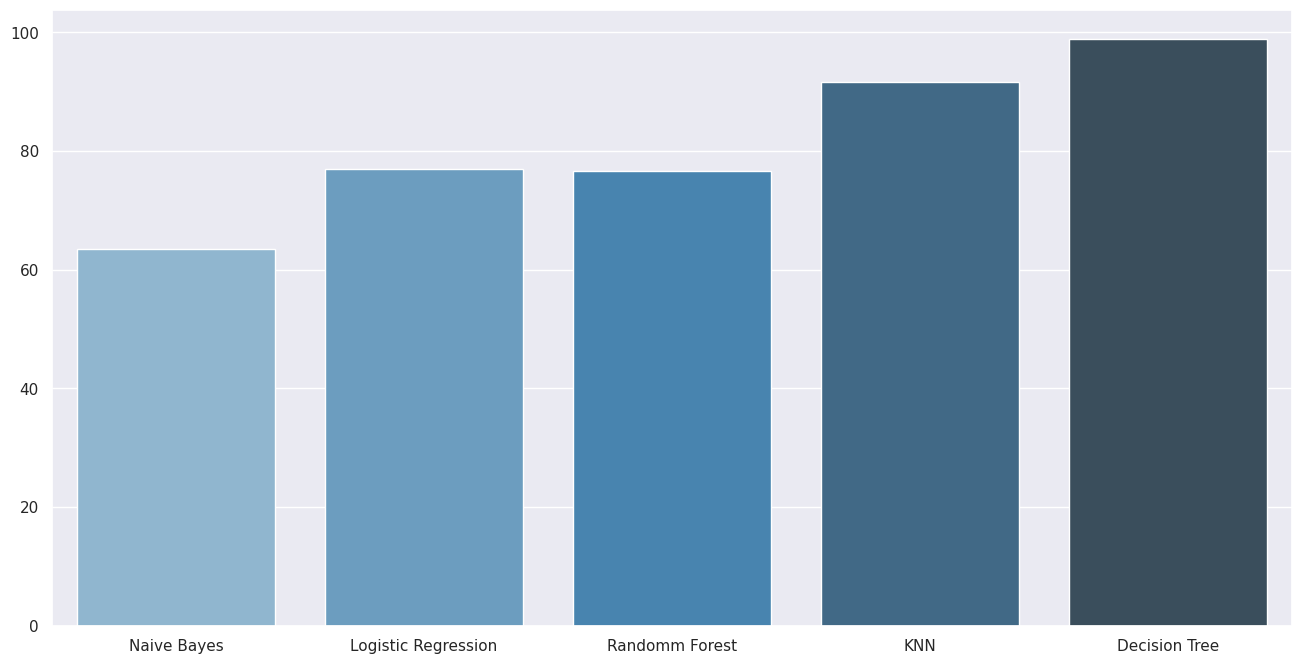

In [50]:
classifier = ['Naive Bayes', 'Logistic Regression', 'Randomm Forest', 'KNN', 'Decision Tree']
model_accuracy = [gnb_accuracy, lreg_accuracy, rfc_accuracy, knn_accuracy, dtree_accuracy]
plt.figure(figsize=(16,8))
sns.barplot(x = classifier, y = model_accuracy, palette="Blues_d")


Observations:

    Both KNN and Decision Tree achieved an accuracy over 90%.
    Decision Tree achieved the highest accuracy because the dataset is non-linear containing both categorical and continuous data.

